<a href="https://colab.research.google.com/github/anshulkr69/CryptoTier-ML/blob/main/dataIngestion_and_modelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd

In [93]:
# Data ingestion thru api

import requests
from google.colab import userdata

api_key = userdata.get('api_key')
url = "https://api.coingecko.com/api/v3/coins/markets"

page = 1
query = {"x_cg_demo_api_key":f'{api_key}', 'vs_currency':'inr', 'page':page}

response = requests.get(url, params = query)
response.status_code

200

In [94]:
response.json()[0]

{'id': 'bitcoin',
 'symbol': 'btc',
 'name': 'Bitcoin',
 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400',
 'current_price': 6232877,
 'market_cap': 125004253271256,
 'market_cap_rank': 1,
 'fully_diluted_valuation': 125004446466856,
 'total_volume': 1417067655179,
 'high_24h': 6234982,
 'low_24h': 6151124,
 'price_change_24h': 49430,
 'price_change_percentage_24h': 0.79939,
 'market_cap_change_24h': 979982022112,
 'market_cap_change_percentage_24h': 0.79015,
 'circulating_supply': 20058075.0,
 'total_supply': 20058106.0,
 'max_supply': 21000000.0,
 'ath': 11187013,
 'ath_change_percentage': -44.28471,
 'ath_date': '2025-10-06T18:57:42.558Z',
 'atl': 3993.42,
 'atl_change_percentage': 155978.70476,
 'atl_date': '2013-07-05T00:00:00.000Z',
 'roi': None,
 'last_updated': '2026-07-18T19:48:51.672Z'}

In [95]:
res = []
res.append(response.json())
print(res)

[[{'id': 'bitcoin', 'symbol': 'btc', 'name': 'Bitcoin', 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400', 'current_price': 6232877, 'market_cap': 125004253271256, 'market_cap_rank': 1, 'fully_diluted_valuation': 125004446466856, 'total_volume': 1417067655179, 'high_24h': 6234982, 'low_24h': 6151124, 'price_change_24h': 49430, 'price_change_percentage_24h': 0.79939, 'market_cap_change_24h': 979982022112, 'market_cap_change_percentage_24h': 0.79015, 'circulating_supply': 20058075.0, 'total_supply': 20058106.0, 'max_supply': 21000000.0, 'ath': 11187013, 'ath_change_percentage': -44.28471, 'ath_date': '2025-10-06T18:57:42.558Z', 'atl': 3993.42, 'atl_change_percentage': 155978.70476, 'atl_date': '2013-07-05T00:00:00.000Z', 'roi': None, 'last_updated': '2026-07-18T19:48:51.672Z'}, {'id': 'ethereum', 'symbol': 'eth', 'name': 'Ethereum', 'image': 'https://coin-images.coingecko.com/coins/images/279/large/ethereum.png?1696501628', 'current_price': 179487, 

In [96]:
len(response.json())

100

In [97]:
from collections import deque
res = deque([])
for i in range(10):
  page = i+1
  query = {"x_cg_demo_api_key":f'{api_key}', 'vs_currency':'inr', 'page':f"{page}"}

  response = requests.get(url, params = query)
  res.extend(response.json())
len(res)

1000

In [98]:
# We will extract only the useful features from the dataset to predict the rank of a cryptocoin
extract_cols = ['current_price','market_cap','fully_diluted_valuation','total_volume','price_change_percentage_24h','market_cap_change_percentage_24h','circulating_supply','total_supply','max_supply','ath', 'ath_change_percentage','atl','atl_change_percentage','market_cap_rank']

In [99]:
data = deque()
for i in res:
  data.extend(i[k] for k in extract_cols)

In [100]:
# reshaping the data.
data_arr = np.reshape(np.array(data),(int(14000/len(extract_cols)),len(extract_cols)))

In [101]:
data_arr.shape

(1000, 14)

In [102]:
raw_df = pd.DataFrame(data_arr, columns = extract_cols)
raw_df.head()

,current_price,market_cap,fully_diluted_valuation,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage,market_cap_rank
0,6232877,125004253271256,125004446466856,1417067655179,0.79939,0.79015,20058075.0,20058106.0,21000000.0,11187013,-44.28471,3993.42,155978.70476,1
1,179487,21659247041278,21659247041278,411014463491,0.97305,0.95151,120682850.001857,120682850.001857,None,431946,-58.44687,28.13,637934.17492,2
2,96.57,17791093634284,18319055202152,2246617148198,0.19564,0.2103,184223396523.25531,189690338312.546204,None,105.52,-8.47424,36.86,162.01274,3
3,55117,7339420109671,7339420039124,39691161033,0.71992,0.70887,133166000.21,133165998.93,200000000.0,121422,-54.60681,2.58,2132314.19897,4
4,96.63,7080648434464,7084960463981,453860006577,0.19959,0.20482,73275129640.205978,73319753310.591766,None,96.98,-0.35717,65.31,47.96568,5


In [103]:
# Now there is very obvious column that needs to be dropped!!

raw_df.drop('market_cap',axis = 1,inplace = True)

In [104]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   current_price                     1000 non-null   object
 1   fully_diluted_valuation           1000 non-null   object
 2   total_volume                      956 non-null    object
 3   price_change_percentage_24h       978 non-null    object
 4   market_cap_change_percentage_24h  978 non-null    object
 5   circulating_supply                1000 non-null   object
 6   total_supply                      1000 non-null   object
 7   max_supply                        632 non-null    object
 8   ath                               1000 non-null   object
 9   ath_change_percentage             1000 non-null   object
 10  atl                               1000 non-null   object
 11  atl_change_percentage             1000 non-null   object
 12  market_cap_rank      

In [105]:
raw_df.drop('max_supply',axis = 1, inplace = True)

dropped max_supply because it had only ~60% data.

In [106]:
raw_df.describe().T

,count,unique,top,freq
current_price,1000.0,899.0,9.664000e+01,22.0
fully_diluted_valuation,1000.0,1000.0,1.289455e+09,1.0
total_volume,956.0,951.0,0.000000e+00,6.0
price_change_percentage_24h,978.0,953.0,1.997500e-01,15.0
market_cap_change_percentage_24h,978.0,958.0,1.906100e-01,8.0
circulating_supply,1000.0,944.0,1.000000e+09,21.0
total_supply,1000.0,726.0,1.000000e+09,125.0
ath,1000.0,957.0,9.701000e+01,12.0
ath_change_percentage,1000.0,980.0,-3.858500e-01,10.0
atl,1000.0,937.0,8.532000e+01,12.0


In [107]:
# Lets see the heatmap

corr = raw_df.corr()

In [108]:
corr

,current_price,fully_diluted_valuation,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,ath,ath_change_percentage,atl,atl_change_percentage,market_cap_rank
current_price,1.000000,0.552804,0.298362,0.002879,-0.002403,-0.002454,-0.002375,-0.001329,0.075378,0.817253,-0.002306,-0.030805
fully_diluted_valuation,0.552804,1.000000,0.654305,0.002643,-0.001929,-0.001983,-0.001926,-0.001152,0.041595,-0.002982,-0.001949,-0.096108
total_volume,0.298362,0.654305,1.000000,0.003360,-0.002187,-0.002200,-0.002140,0.336524,0.072678,-0.003201,-0.002169,-0.109156
price_change_percentage_24h,0.002879,0.002643,0.003360,1.000000,0.026711,0.000869,0.000915,-0.001037,0.048230,0.001360,0.000062,-0.011356
market_cap_change_percentage_24h,-0.002403,-0.001929,-0.002187,0.026711,1.000000,-0.001118,-0.001078,-0.001152,-0.026734,-0.001996,-0.001098,0.007293
circulating_supply,-0.002454,-0.001983,-0.002200,0.000869,-0.001118,1.000000,0.999952,-0.001068,-0.025900,-0.001945,-0.001065,-0.011505
total_supply,-0.002375,-0.001926,-0.002140,0.000915,-0.001078,0.999952,1.000000,-0.001034,-0.025276,-0.001883,-0.001031,-0.011369
ath,-0.001329,-0.001152,0.336524,-0.001037,-0.001152,-0.001068,-0.001034,1.000000,-0.029285,-0.001130,-0.001004,-0.036930
ath_change_percentage,0.075378,0.041595,0.072678,0.048230,-0.026734,-0.025900,-0.025276,-0.029285,1.000000,0.073271,-0.027205,-0.190020
atl,0.817253,-0.002982,-0.003201,0.001360,-0.001996,-0.001945,-0.001883,-0.001130,0.073271,1.000000,-0.001828,0.006414


<Axes: >

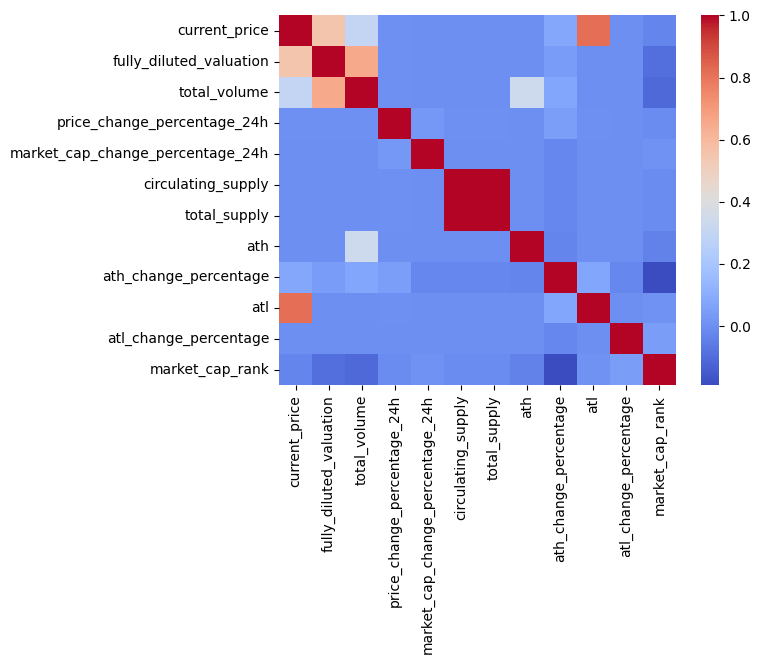

In [109]:
from matplotlib.colors import Colormap
import seaborn as sns

sns.heatmap(corr,cmap = 'coolwarm')

In [110]:
!pip install ydata_profiling

In [111]:
from ydata_profiling import ProfileReport

In [112]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   current_price                     1000 non-null   object
 1   fully_diluted_valuation           1000 non-null   object
 2   total_volume                      956 non-null    object
 3   price_change_percentage_24h       978 non-null    object
 4   market_cap_change_percentage_24h  978 non-null    object
 5   circulating_supply                1000 non-null   object
 6   total_supply                      1000 non-null   object
 7   ath                               1000 non-null   object
 8   ath_change_percentage             1000 non-null   object
 9   atl                               1000 non-null   object
 10  atl_change_percentage             1000 non-null   object
 11  market_cap_rank                   1000 non-null   object
dtypes: object(12)
memory 

In [113]:
raw_df.dropna(inplace = True)

In [114]:
# This will give error if we dont change the data types to numeric type

raw_df = raw_df.astype(dtype = 'float')
raw_df.shape

(937, 12)

In [115]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 937 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   current_price                     937 non-null    float64
 1   fully_diluted_valuation           937 non-null    float64
 2   total_volume                      937 non-null    float64
 3   price_change_percentage_24h       937 non-null    float64
 4   market_cap_change_percentage_24h  937 non-null    float64
 5   circulating_supply                937 non-null    float64
 6   total_supply                      937 non-null    float64
 7   ath                               937 non-null    float64
 8   ath_change_percentage             937 non-null    float64
 9   atl                               937 non-null    float64
 10  atl_change_percentage             937 non-null    float64
 11  market_cap_rank                   937 non-null    float64
dtypes: float64(12

In [116]:
# profile = ProfileReport(raw_df, title = 'Crypto coins EDA', minimal = True)
# profile.to_file('/content/drive/MyDrive/Datasets/crypto_coins_report.html')

In [117]:
# Turning the target column into quantiles

quantiles = [0.0, 0.1, 0.25, 0.50, 0.75, 1.0]
labels = ['Top 10%', 'Top 25%', 'Top 50%', 'Top 75%', 'Rest']

raw_df['market_percentile'] = pd.qcut(raw_df.market_cap_rank, q = quantiles, labels = labels)

In [118]:
raw_df.drop(['fully_diluted_valuation','market_cap_rank'], axis = 1, inplace = True)

In [120]:
raw_df.sample(5)

,current_price,total_volume,price_change_percentage_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,ath,ath_change_percentage,atl,atl_change_percentage,market_percentile
159,96.60000,2.395330e+08,0.18655,0.78056,2.074024e+08,2.074028e+08,96.93000,-0.32498,7.857000e+01,22.96886,Top 25%
520,0.00001,7.181431e+08,-1.61901,-1.59662,3.905620e+14,3.905620e+14,0.00034,-97.16563,3.702350e-07,2503.47634,Top 75%
161,2871.36000,1.406073e+06,2.24704,0.00000,6.941665e+06,6.941665e+06,4664.30000,-38.43964,2.485430e+03,15.52786,Top 25%
16,18.09000,8.566892e+09,0.32868,0.40080,3.415716e+10,5.000179e+10,55.54000,-67.51041,2.966141e-02,60737.80549,Top 10%
287,103.15000,2.007302e+08,1.64719,1.65075,7.869700e+07,1.000000e+08,1799.83000,-94.27973,3.033000e+01,239.43299,Top 50%


In [119]:
raw_df.shape

(937, 11)

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(raw_df.iloc[:,0:-1], raw_df.iloc[:,-1], test_size = 0.2, random_state = 42)

In [211]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 150,oob_score = True, max_depth = 8)
rf.fit(X_train, y_train)
rf.oob_score_

0.5727636849132176

In [198]:
importance = rf.feature_importances_

In [199]:
importance

array([0.14098957, 0.14956636, 0.06327544, 0.06120084, 0.16057241,
       0.10586609, 0.07524542, 0.08176415, 0.08262195, 0.07889775])

<BarContainer object of 10 artists>

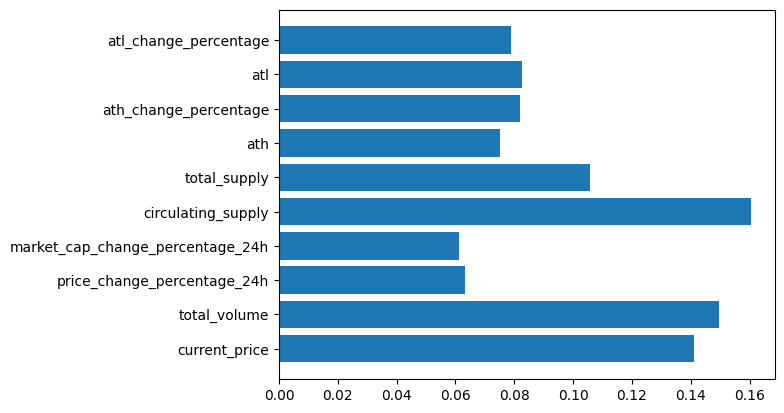

In [200]:
import matplotlib.pyplot as plt

plt.barh(raw_df.columns[:-1], importance)

In [212]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

In [213]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Rest       0.65      0.70      0.67        46
     Top 10%       0.82      0.70      0.76        20
     Top 25%       0.48      0.64      0.55        22
     Top 50%       0.65      0.56      0.60        55
     Top 75%       0.49      0.49      0.49        45

    accuracy                           0.60       188
   macro avg       0.62      0.62      0.61       188
weighted avg       0.61      0.60      0.60       188



In [214]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[32,  0,  1,  2, 11],
       [ 0, 14,  6,  0,  0],
       [ 0,  2, 14,  6,  0],
       [ 4,  1,  7, 31, 12],
       [13,  0,  1,  9, 22]])